# Enhanced Corelation Matrix with Posterior Distributions

Data Information:
Data shape: (92, 11)

Column names:
['Year', 'MAT_C', 'MAP_C', 'Glaciercover', 'Lake area', 'GMB', 'SDR', 'IC', 'SlidV_mPERyr', 'ER_mmPERyr', 'Lake type']

First 5 rows:
   Year     MAT_C       MAP_C  Glaciercover   Lake area     GMB       SDR  \
0  1990 -8.915011  141.444749     17.440952  292.612276 -0.0025  0.035297   
1  1991 -9.596413  148.289544     17.410219  295.945726 -0.1320  0.035243   
2  1992 -9.538834  252.213566     17.379485  302.236903  0.4125  0.035234   
3  1993 -9.141202  177.464794     17.348764  339.792615  0.6645  0.035508   
4  1994 -8.859141   98.076960     17.318031  332.298593 -0.0125  0.035642   

         IC  SlidV_mPERyr  ER_mmPERyr       Lake type  
0 -5.703854      6.000000    0.122697  Aksayqin lake   
1 -5.706988      8.444444    0.130794  Aksayqin lake   
2 -5.707607           NaN    0.138892  Aksayqin lake   
3 -5.691392           NaN    0.146990  Aksayqin lake   
4 -5.683419           NaN    0.155088  Aksayqin lake   

Cleaned data

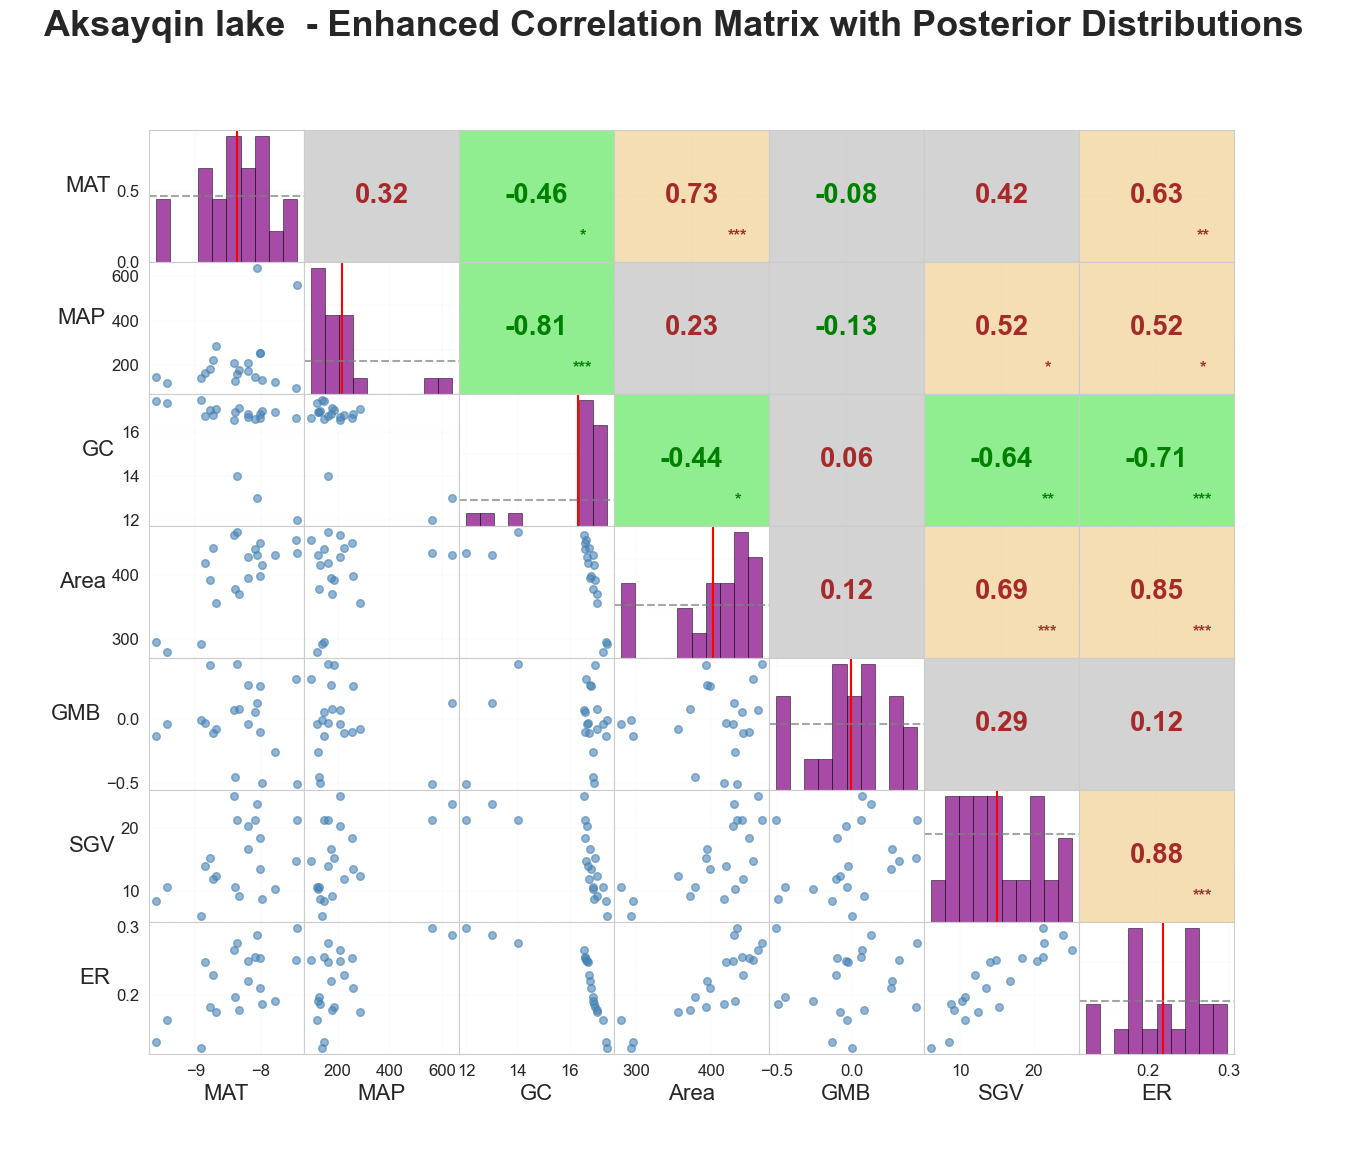


Creating Enhanced Correlation Matrix for Ranwu lake...
Correlation matrix saved to: D:\Research\02Paper\Data\2highline\归因\AGR3_Ranwu_lake_Correlation_Matrix0324.png


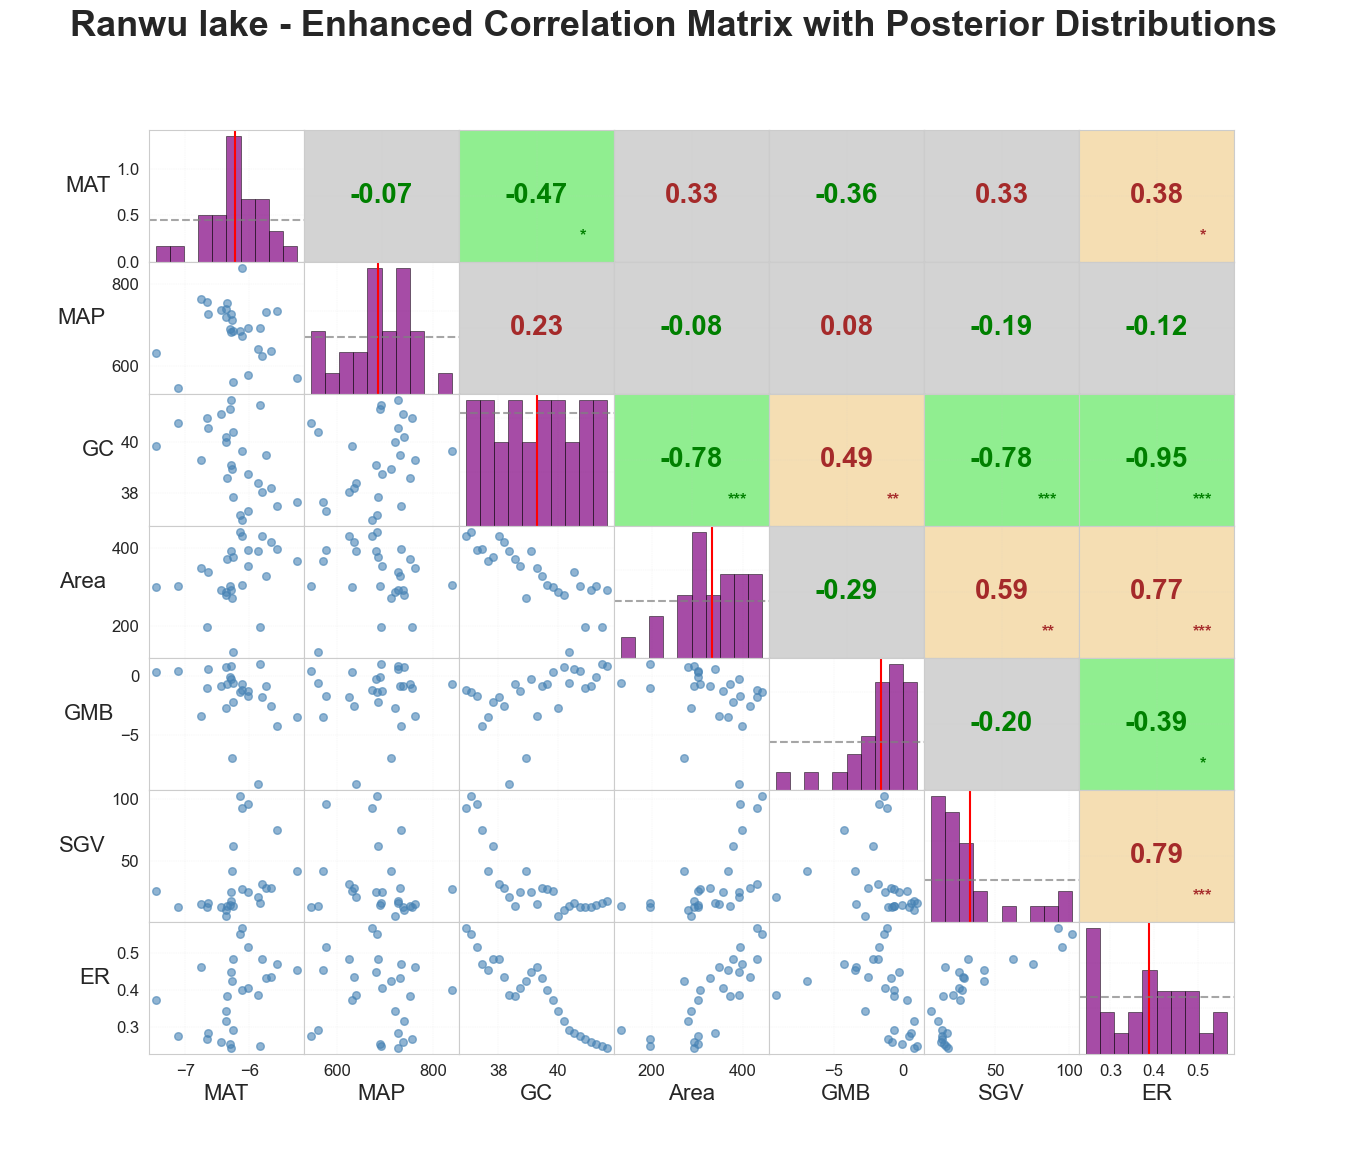


Creating Enhanced Correlation Matrix for Galan lake...
Correlation matrix saved to: D:\Research\02Paper\Data\2highline\归因\AGR3_Galan_lake_Correlation_Matrix0324.png


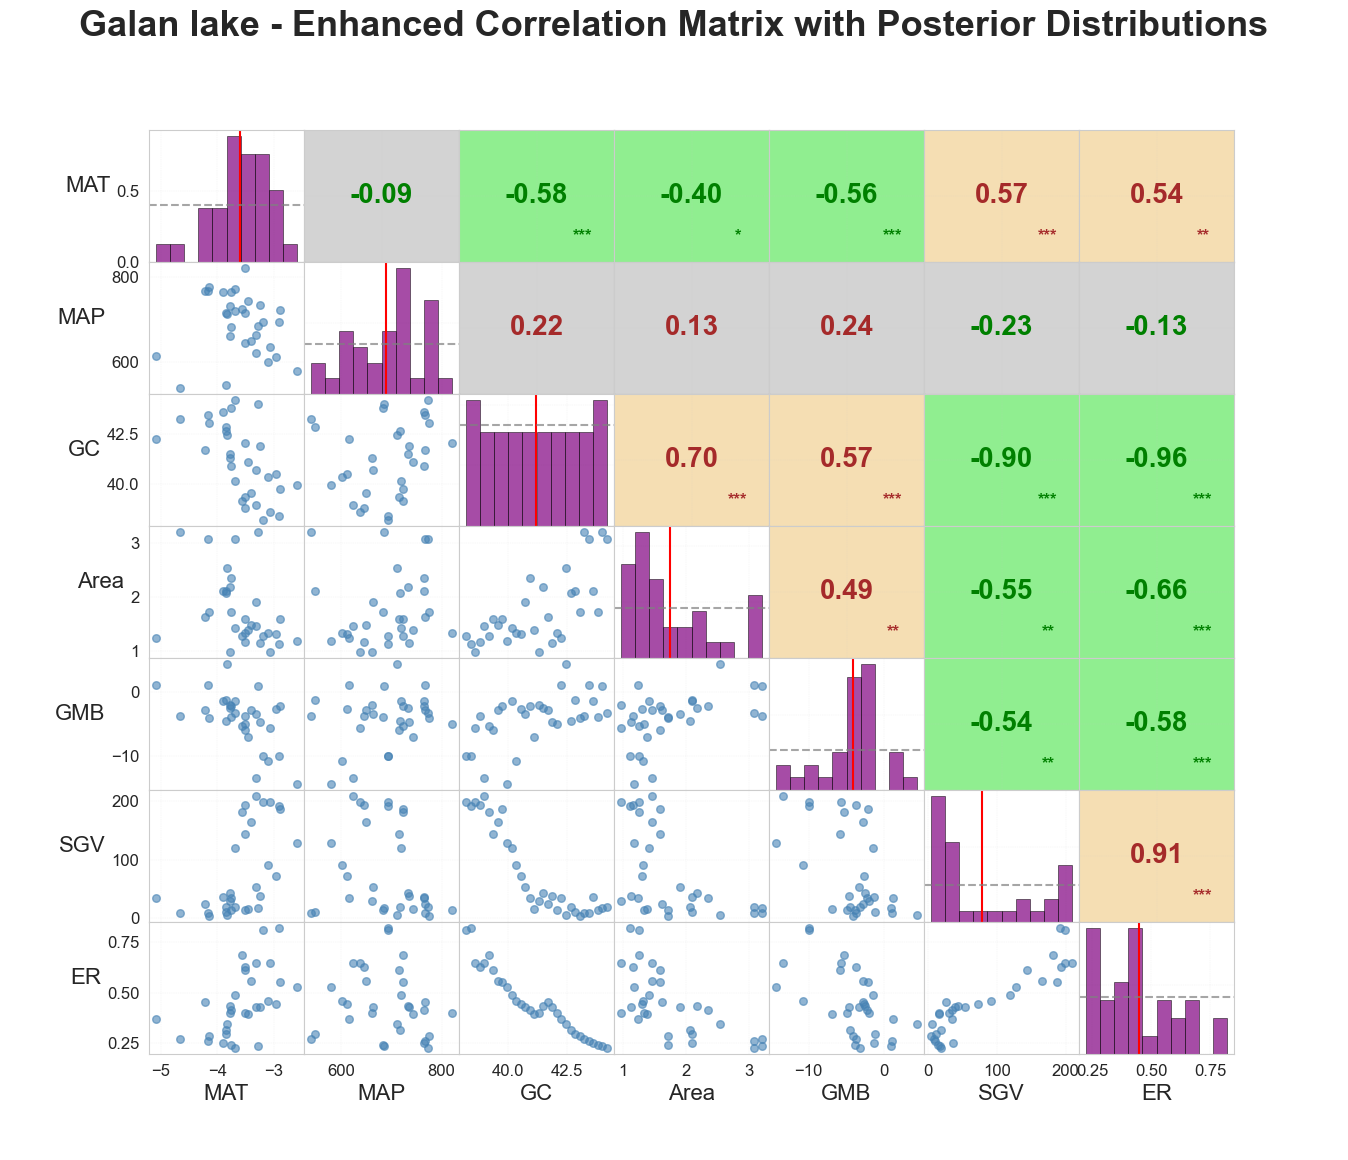


6. Statistical Analysis Results Summary

Aksayqin lake  Analysis Results:
----------------------------------------
Sample size: 21
Analysis type: full

1. Top 3 most important factors overall:
   1. Glacier cover: 0.723
   2. Summer glacier velocity: 0.129
   3. Lake area: 0.108

2. Standardized regression coefficient analysis:
   1. Lake area: Positive effect (weak) (coefficient: 0.022)
   2. Summer glacier velocity: Positive effect (weak) (coefficient: 0.020)
   3. Glacier cover: Negative effect (weak) (coefficient: -0.012)

3. Feature importance trends with glacier cover:
   - Summer glacier velocity: decreasing with glacier cover (significant) (slope: -0.108963)
   - Glacier mass balance: decreasing with glacier cover (significant) (slope: -0.002687)
   - Lake area: increasing with glacier cover (significant) (slope: 0.055751)

Ranwu lake Analysis Results:
----------------------------------------
Sample size: 27
Analysis type: full

1. Top 3 most important factors overall:
   1. G

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set English font and style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24
sns.set_style("whitegrid")

# Customizable legend names
LEGEND_NAMES = {
    'SlidV_mPERyr': 'Summer glacier velocity',
    'GMB': 'Glacier mass balance',
    'Lake area': 'Lake area',
    'MAT_C': 'Mean annual temperature',
    'MAP_C': 'Mean annual precipitation',
    'Glaciercover': 'Glacier cover',
    'ER_mmPERyr': 'Erosion rate'
}

# Read data
file_path = r"D:\Research\02Paper\Data\2highline\归因\AGR3_Table1010.xlsx"
df = pd.read_excel(file_path)

# Display basic data information
print("Data Information:")
print(f"Data shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# Check and clean data
required_columns = ['Year', 'MAT_C', 'MAP_C', 'Glaciercover', 'Lake area', 'GMB', 'SlidV_mPERyr', 'ER_mmPERyr', 'Lake type']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Warning: Missing columns: {missing_columns}")
    # Only use existing columns
    required_columns = [col for col in required_columns if col in df.columns]

# Data cleaning
df_clean = df[required_columns].dropna()
print(f"\nCleaned data shape: {df_clean.shape}")

# Check actual lake types in data
print(f"\nLake types present in data:")
lake_types_in_data = df_clean['Lake type'].unique()
print(lake_types_in_data)

# Define analysis variables
feature_vars = ['MAT_C', 'MAP_C', 'Glaciercover', 'Lake area', 'GMB', 'SlidV_mPERyr']
target_var = 'ER_mmPERyr'

print(f"\nFeature variables used: {feature_vars}")
print(f"Target variable: {target_var}")

# Analyze by lake type
lake_results = {}

for lake_type in lake_types_in_data:
    print(f"\n{'='*60}")
    print(f"Analyzing lake type: {lake_type}")
    print(f"{'='*60}")
    
    # Filter data for current lake type
    lake_data = df_clean[df_clean['Lake type'] == lake_type].copy()
    
    print(f"{lake_type} sample size: {len(lake_data)}")
    
    if len(lake_data) < 5:  # If sample size is too small, perform simplified analysis
        print(f"Warning: {lake_type} has limited samples ({len(lake_data)}), performing simplified analysis")
        
        # Store basic information
        lake_results[lake_type] = {
            'data': lake_data,
            'sample_size': len(lake_data),
            'analysis_type': 'simplified'
        }
        
        # Perform basic statistical description
        print(f"\n{lake_type} - Basic statistics:")
        print(lake_data[feature_vars + [target_var]].describe())
        
        # Calculate simple correlations
        print(f"\n{lake_type} - Correlation with erosion rate:")
        for var in feature_vars:
            if len(lake_data) >= 2:
                correlation, p_value = stats.pearsonr(lake_data[var], lake_data[target_var])
                print(f"  {LEGEND_NAMES.get(var, var)}: r = {correlation:.3f}, p = {p_value:.3f}")
        
        continue
    
    # Store current lake analysis results
    lake_results[lake_type] = {
        'data': lake_data,
        'feature_importance': None,
        'standardized_coef': None,
        'window_results': None,
        'glacier_cover_ranges': None,
        'sample_size': len(lake_data),
        'analysis_type': 'full'
    }
    
    # 1. Random forest feature importance analysis
    print(f"\n1. {lake_type} - Random Forest Feature Importance Analysis")
    
    # Prepare data
    X = lake_data[feature_vars]
    y = lake_data[target_var]
    
    # Overall random forest
    rf_overall = RandomForestRegressor(n_estimators=400, random_state=42, max_depth=8)
    rf_overall.fit(X, y)
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'Variable': feature_vars,
        'Importance': rf_overall.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    lake_results[lake_type]['feature_importance'] = feature_importance
    print("Feature importance:")
    print(feature_importance)
    
    # 2. Multiple regression standardized coefficient analysis
    print(f"\n2. {lake_type} - Multiple Regression Standardized Coefficient Analysis")
    
    # Standardize data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_vars)
    
    # Multiple linear regression
    lr_model = LinearRegression()
    lr_model.fit(X_scaled_df, y)
    
    # Standardized coefficients
    standardized_coef = pd.DataFrame({
        'Variable': feature_vars,
        'Standardized_Coefficient': lr_model.coef_,
        'Absolute_Effect': np.abs(lr_model.coef_)
    }).sort_values('Absolute_Effect', ascending=False)
    
    lake_results[lake_type]['standardized_coef'] = standardized_coef
    print("Standardized regression coefficients:")
    print(standardized_coef)
    
    # 3. Interaction effect analysis
    print(f"\n3. {lake_type} - Interaction Effect Analysis")
    
    # Prepare data for interaction effect analysis
    interaction_data = lake_data.copy()
    
    # Build interaction model formula
    formula = f"{target_var} ~ "
    for var in feature_vars:
        if var != 'Glaciercover':  # Glaciercover as main interaction variable
            formula += f" {var} + {var}:Glaciercover +"
    formula = formula[:-1]  # Remove the last plus sign
    
    try:
        interaction_model = smf.ols(formula, data=interaction_data).fit()
        
        # Extract significant interaction terms
        significant_interactions = []
        for param in interaction_model.params.index:
            if 'Glaciercover' in param and param != 'Glaciercover':
                p_value = interaction_model.pvalues[param]
                if p_value < 0.1:  # Relaxed significance level
                    significant_interactions.append((param, interaction_model.params[param], p_value))
        
        print("Significant interaction effects:")
        for interaction, coef, p_val in significant_interactions:
            print(f"{interaction}: coefficient={coef:.4f}, p-value={p_val:.4f}")
            
    except Exception as e:
        print(f"Interaction model fitting failed: {e}")
    
    # 4. Moving window feature importance analysis
    print(f"\n4. {lake_type} - Moving Window Feature Importance Analysis")
    
    # Sort data by glacier cover
    lake_sorted = lake_data.sort_values('Glaciercover')
    
    # Define window parameters - adapt based on sample size
    if len(lake_sorted) >= 20:
        window_size = 15
        step_size = 5
    elif len(lake_sorted) >= 15:
        window_size = 10
        step_size = 4
    elif len(lake_sorted) >= 10:
        window_size = 8
        step_size = 3
    else:
        window_size = min(6, len(lake_sorted) - 2)
        step_size = max(2, window_size // 2)
    
    # Initialize result storage
    window_results = []
    glacier_cover_ranges = []
    
    # Perform moving window analysis
    for start_idx in range(0, len(lake_sorted) - window_size + 1, step_size):
        end_idx = start_idx + window_size
        window_data = lake_sorted.iloc[start_idx:end_idx]
        
        glacier_cover_mean = window_data['Glaciercover'].mean()
        
        if len(window_data) >= 5:  # Ensure sufficient samples
            X_window = window_data[feature_vars]
            y_window = window_data[target_var]
            
            # Random forest for current window
            rf_window = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
            rf_window.fit(X_window, y_window)
            
            # Store results
            window_results.append(rf_window.feature_importances_)
            glacier_cover_ranges.append(glacier_cover_mean)
    
    lake_results[lake_type]['window_results'] = window_results
    lake_results[lake_type]['glacier_cover_ranges'] = glacier_cover_ranges
    
    if window_results:
        print(f"Moving window analysis completed: {len(window_results)} windows")
        print(f"Glacier cover range: {min(glacier_cover_ranges):.1f}% to {max(glacier_cover_ranges):.1f}%")
    else:
        print("Moving window analysis cannot be performed, insufficient sample size")

# 5. Visualization - Enhanced Correlation Matrix for lakes with sufficient data
print("\n" + "="*50)
print("5. Visualization - Enhanced Correlation Matrix")
print("="*50)

for lake_type in lake_results.keys():
    lake_info = lake_results[lake_type]
    
    if lake_info['analysis_type'] == 'simplified':
        print(f"\nSkipping visualization for {lake_type} - insufficient sample size ({lake_info['sample_size']})")
        continue
    
    print(f"\nCreating Enhanced Correlation Matrix for {lake_type}...")
    
    # Get current lake data
    lake_data = lake_info['data']
    
    # Create new figure for saving - only keep correlation matrix
    fig_save = plt.figure(figsize=(14, 12))
    
    # Create single subplot for correlation matrix
    ax_main = fig_save.add_subplot(111)
    
    # Calculate correlation matrix
    correlation_vars = feature_vars + [target_var]
    corr_matrix = lake_data[correlation_vars].corr()
    
    # Calculate p-value matrix
    p_value_matrix = np.zeros_like(corr_matrix)
    for i in range(len(correlation_vars)):
        for j in range(len(correlation_vars)):
            if i != j:
                corr, p_value = stats.pearsonr(lake_data[correlation_vars[i]], lake_data[correlation_vars[j]])
                p_value_matrix[i, j] = p_value
            else:
                p_value_matrix[i, j] = 1.0
    
    # Get ax_main position information
    ax_main_pos = ax_main.get_position()
    ax_main_x0, ax_main_y0, ax_main_width, ax_main_height = ax_main_pos.x0, ax_main_pos.y0, ax_main_pos.width, ax_main_pos.height
    
    # Create subplot grid within ax_main area
    n_vars = len(correlation_vars)
    grid_width = ax_main_width / n_vars
    grid_height = ax_main_height / n_vars
    
    # Custom labels
    custom_labels = [LEGEND_NAMES.get(var, var) for var in correlation_vars]
    
    # Create abbreviation mapping
    abbrev_mapping = {
        'Summer glacier velocity': 'SGV',
        'Glacier mass balance': 'GMB',
        'Lake area': 'Area',
        'Mean annual temperature': 'MAT',
        'Mean annual precipitation': 'MAP',
        'Glacier cover': 'GC',
        'Erosion rate': 'ER'
    }
    
    # Create axis labels (using abbreviations)
    axis_labels = [abbrev_mapping.get(label, label) for label in custom_labels]
    
    # Heatmap configuration
    HEATMAP_CONFIG = {
        'font_sizes': {
            'axis_label': 16,
            'correlation': 14,
            'title': 18
        }
    }
    
    # Iterate through all cells, create subplots within ax_main area
    for i in range(n_vars):
        for j in range(n_vars):
            # Calculate subplot position
            sub_x0 = ax_main_x0 + j * grid_width
            sub_y0 = ax_main_y0 + (n_vars - i - 1) * grid_height
            
            # Create subplot
            ax_sub = fig_save.add_axes([sub_x0, sub_y0, grid_width, grid_height])
            
            if i == j:  # Diagonal: posterior distribution histogram
                data = lake_data[correlation_vars[i]]
                n, bins, patches = ax_sub.hist(data, color='purple', alpha=0.7, bins=10, 
                                             density=True, edgecolor='black', linewidth=0.5)
                mean_val = data.mean()
                ax_sub.axvline(x=mean_val, color='red', linestyle='-', linewidth=1.5)
                
                x_min, x_max = data.min(), data.max()
                if x_max > x_min:
                    prior_height = 1.0 / (x_max - x_min)
                    ax_sub.axhline(y=prior_height, color='gray', linestyle='--', 
                                  alpha=0.7, linewidth=1.5)
                
            elif i > j:  # Lower triangle: scatter plot
                x_data = lake_data[correlation_vars[j]]
                y_data = lake_data[correlation_vars[i]]
                ax_sub.scatter(x_data, y_data, alpha=0.6, s=30, color='steelblue')
                
            else:  # Upper triangle: correlation values
                r = corr_matrix.iloc[i, j]
                p = p_value_matrix[i, j]
                
                # Set background color based on significance
                if p < 0.05:
                    if r < 0:
                        facecolor = 'lightgreen'
                    else:
                        facecolor = 'wheat'
                else:
                    facecolor = 'lightgray'
                
                ax_sub.set_facecolor(facecolor)
                
                # Display correlation value
                color = 'green' if r < 0 else 'brown'
                ax_sub.text(0.5, 0.5, f'{r:.2f}', 
                          ha='center', va='center', 
                          fontsize=HEATMAP_CONFIG['font_sizes']['correlation']+6, 
                          fontweight='bold', color=color, transform=ax_sub.transAxes)
                
                # Add p-value star marker
                if p < 0.001:
                    sig_mark = '***'
                elif p < 0.01:
                    sig_mark = '**'
                elif p < 0.05:
                    sig_mark = '*'
                else:
                    sig_mark = ''
                
                if sig_mark:
                    ax_sub.text(0.8, 0.2, sig_mark, 
                              ha='center', va='center', 
                              fontsize=HEATMAP_CONFIG['font_sizes']['correlation']-2, 
                              fontweight='bold', color=color, transform=ax_sub.transAxes)
            
            # Set axis labels
            if i == n_vars - 1:
                ax_sub.set_xlabel(axis_labels[j], 
                                fontsize=HEATMAP_CONFIG['font_sizes']['axis_label'], 
                                rotation=0, ha='center')
            else:
                ax_sub.set_xticklabels([])
                
            if j == 0:
                ax_sub.set_ylabel(axis_labels[i], 
                                fontsize=HEATMAP_CONFIG['font_sizes']['axis_label'], 
                                rotation=0, ha='right')
            else:
                ax_sub.set_yticklabels([])
            
            ax_sub.grid(True, alpha=0.3, linestyle='--', linewidth=0.3)
            ax_sub.tick_params(axis='both', which='major', 
                              labelsize=HEATMAP_CONFIG['font_sizes']['correlation']-2)
    
    # Set overall title
    fig_save.suptitle(f'{lake_type} - Enhanced Correlation Matrix with Posterior Distributions', 
                     fontsize=HEATMAP_CONFIG['font_sizes']['title']+8, fontweight='bold', y=0.98)
    
    # Hide original ax_main borders
    ax_main.set_xticks([])
    ax_main.set_yticks([])
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    ax_main.spines['bottom'].set_visible(False)
    ax_main.spines['left'].set_visible(False)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save figure
    safe_lake_name = lake_type.replace(' ', '_').replace('/', '_')
    output_path = f"D:\\Research\\02Paper\\Data\\2highline\\归因\\AGR3_{safe_lake_name}_Correlation_Matrix0324.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Correlation matrix saved to: {output_path}")
    
    # Display figure
    plt.show()
    
    # Close current figure to free memory
    plt.close(fig_save)

# 6. Statistical validation and result summary
print("\n" + "="*50)
print("6. Statistical Analysis Results Summary")
print("="*50)

for lake_type, lake_info in lake_results.items():
    print(f"\n{lake_type} Analysis Results:")
    print("-" * 40)
    print(f"Sample size: {lake_info['sample_size']}")
    print(f"Analysis type: {lake_info['analysis_type']}")
    
    if lake_info['analysis_type'] == 'simplified':
        print("Only basic statistical analysis performed due to limited sample size")
        continue
    
    feature_importance = lake_info['feature_importance']
    standardized_coef = lake_info['standardized_coef']
    
    print("\n1. Top 3 most important factors overall:")
    top3 = feature_importance.head(3)
    for i, (_, row) in enumerate(top3.iterrows(), 1):
        factor_name = LEGEND_NAMES.get(row['Variable'], row['Variable'])
        print(f"   {i}. {factor_name}: {row['Importance']:.3f}")
    
    print("\n2. Standardized regression coefficient analysis:")
    top_effect = standardized_coef.head(3)
    for i, (_, row) in enumerate(top_effect.iterrows(), 1):
        effect_direction = "Positive" if row['Standardized_Coefficient'] > 0 else "Negative"
        significance = " (significant)" if abs(row['Standardized_Coefficient']) > 0.1 else " (weak)"
        factor_name = LEGEND_NAMES.get(row['Variable'], row['Variable'])
        print(f"   {i}. {factor_name}: {effect_direction} effect{significance} (coefficient: {row['Standardized_Coefficient']:.3f})")
    
    if lake_info['window_results']:
        print("\n3. Feature importance trends with glacier cover:")
        for factor in ['SlidV_mPERyr', 'GMB', 'Lake area']:
            if factor in feature_vars:
                factor_idx = feature_vars.index(factor)
                importances = [lake_info['window_results'][i][factor_idx] for i in range(len(lake_info['window_results']))]
                
                if len(importances) >= 2:
                    trend = np.polyfit(lake_info['glacier_cover_ranges'], importances, 1)[0]
                    direction = "increasing" if trend > 0 else "decreasing"
                    significance = " (significant)" if abs(trend) > 0.001 else " (weak)"
                    factor_name = LEGEND_NAMES.get(factor, factor)
                    print(f"   - {factor_name}: {direction} with glacier cover{significance} (slope: {trend:.6f})")

# 7. Save results
print("\n" + "="*50)
print("7. Saving Results")
print("="*50)

# Save statistical results to Excel
with pd.ExcelWriter(r"D:\Research\02Paper\Data\2highline\归因\AGR3_LakeType_Statistical_Results0324.xlsx") as writer:
    for lake_type, lake_info in lake_results.items():
        # Create separate worksheet for each lake
        safe_sheet_name = lake_type.replace(' ', '_').replace('/', '_')[:31]
        
        if lake_info['analysis_type'] == 'full':
            # Save complete analysis results
            lake_info['feature_importance'].to_excel(
                writer, sheet_name=f'{safe_sheet_name}_Feature_Imp', index=False)
            
            lake_info['standardized_coef'].to_excel(
                writer, sheet_name=f'{safe_sheet_name}_Std_Coeff', index=False)
            
            # Save moving window analysis results
            if lake_info['window_results']:
                window_summary = pd.DataFrame({
                    'GlacierCover_Mean': lake_info['glacier_cover_ranges']
                })
                for i, var in enumerate(feature_vars):
                    window_summary[var] = [lake_info['window_results'][j][i] 
                                         for j in range(len(lake_info['window_results']))]
                window_summary.to_excel(
                    writer, sheet_name=f'{safe_sheet_name}_Moving_Win', index=False)
        else:
            # Save simplified analysis results
            summary_df = pd.DataFrame({
                'Metric': ['Sample_Size', 'Analysis_Type'],
                'Value': [lake_info['sample_size'], lake_info['analysis_type']]
            })
            summary_df.to_excel(writer, sheet_name=f'{safe_sheet_name}_Summary', index=False)

print(f"Detailed results saved to: D:\\Research\\02Paper\\Data\\2highline\\归因\\AGR3_LakeType_Statistical_Results0324.xlsx")

print("\n" + "="*50)
print("Analysis Complete!")
print("="*50)